In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct
plt.style.use('mplstyle')

In [2]:
# inputs
nua = np.load('nua.npy')
nc = len(nua)
nuc = nua.mean()/1e6
dnuc = abs(nua[1] - nua[0])/1e6
dnu = np.arange(nc)*dnuc

# redshift params
zz = 1420./nuc -1
r, rp = pfunc.rrprime(zz, 'astropy')
fac = r/(rp*nuc) # theoretically predicted FG wedge boundary: kpara_H = fac*kper
dkl = 0. # fixed buffer

# baseline, ell, kper, kpara
Umin, Umax, Nbin = 6, 220, 20
# edges = np.geomspace(Umin, Umax, Nbin + 1)
# UU = np.sqrt(edges[:-1] * edges[1:])
edges = np.linspace(Umin, Umax, Nbin + 1)
UU = 0.5 * (edges[:-1] + edges[1:])

ell = 2*np.pi*UU
print('ell:', ell)
nell = len(ell)

kper = ell/r
print('kper:', kper)

# PS params # should be dynamically chosen based on Cl.shape
nc1 = nc # nc - 2*NN can be chosen
vfac = rp*r*r*dnuc*(nc1-1) # DCT factor
kpara = 2.*np.pi*np.arange(nc1)/(rp*(2.*nc1-2.)*dnuc)
print('kpara:', kpara[1], kpara[-1])
w = windows.nuttall(2*nc1)[nc1:] # window for Fourier transform
wf = windows.nuttall(nc1) # window for Fourier transform of visibilities
# kper = kpara.copy()

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
KK = PK21[:, 0]
PK = PK21[:, 1]

# EoR power spectrum model in high resolution
KK = np.logspace(np.log10(0.0001), np.log10(10), 10000)
PK = KK**-1

PKm2D = pfunc.get_model_pk_2d(kper, kpara, KK, PK)

Redshift = 8.206729512407456 
Comoving distance (from astropy): 9209.71452683092 Mpc
rprime (from astropy) = 16.98990953034521 Mpc/MHz
ell: [  71.31415324  138.54423602  205.77431881  273.0044016   340.23448438
  407.46456717  474.69464996  541.92473274  609.15481553  676.38489832
  743.6149811   810.84506389  878.07514668  945.30522947 1012.53531225
 1079.76539504 1146.99547783 1214.22556061 1281.4556434  1348.68572619]
kper: [0.00774336 0.01504327 0.02234318 0.02964309 0.036943   0.04424291
 0.05154282 0.05884273 0.06614264 0.07344255 0.08074246 0.08804237
 0.09534228 0.10264219 0.1099421  0.117242   0.12454191 0.13184182
 0.13914173 0.14644164]
kpara: 0.0060270313587951685 4.622733052195895


In [3]:
flag = pfunc.flagdata(nc, mode='NOFLAG', percent = 10) # RANDOM, MWA, NOFLAG
flag = pfunc.flagdata(nc, mode='NOFLAG', percent = 50) # RANDOM, MWA, NOFLAG

In [4]:
fact = r**2
# ml_count = pfunc.covtocl_fast(flag, flag) # counter for normalizition 


Nrea = 100  # number of realizations

# nc1 = nc - 0
# nc1 = np.argmax(ml_count.real == 0) if np.any(ml_count.real == 0) else nc # only where cl is valid, ie, discarding last few delta nu
# kpara1 = 2.*np.pi*np.arange(nc1)/(rp*(2.*nc1-2.)*dnuc)
# w = windows.nuttall(2*nc1)[nc1:] # window for Fourier transform
# print(nc1)

ml = np.zeros((Nrea, nc))

nl = 0
kp = kper[nl]
PKm = np.ones_like(PKm2D[nl,:])

for i in range(Nrea):    
    
    # visibilities 
    VX = pfunc.gaussian_field_1d(PKm) * flag
    VY = pfunc.gaussian_field_1d(PKm) * flag

    # pk from MAPS     
    ml[i] = pfunc.covtocl_fast(VY, VX)          



ml_norm = np.mean(ml.real, axis=0)



/tmp/ipykernel_23342/1158677820.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  ml[i] = pfunc.covtocl_fast(VY, VX)


In [5]:
np.save('ml_norm', ml_norm)

In [6]:
ml_norm[0], ml_norm[1],ml_norm[20]
# (589351.918886323, -2522.595588874297)



(-0.0023852725353372644, -0.003541317802208952, -0.0017135090805441835)

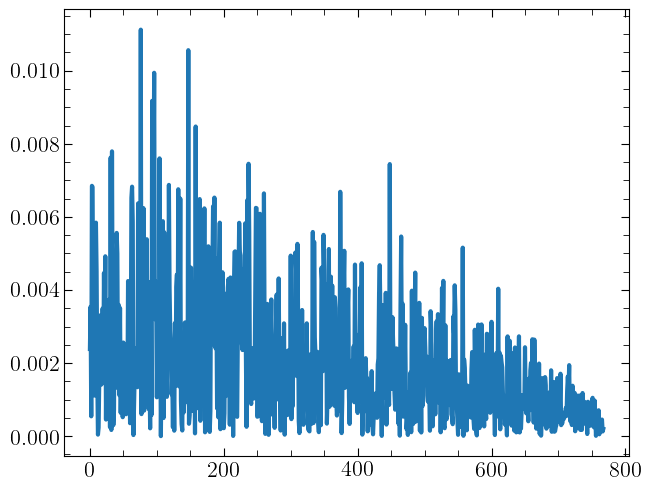

In [7]:
plt.plot(abs(ml_norm))



In [8]:
%

UsageError: Line magic function `%` not found.


In [ ]:
NB = 16
pkssq_re = np.zeros((Nrea, NB))
pks2p_re = np.zeros((Nrea, NB))
kper1 = np.array(kper[nl])

for ii in range(Nrea):
    _, pkssq_re[ii], _ = pfunc.spherical_bin_log(kper1, kpara, pksq_arr[ii], Nbin=NB)
    _, pks2p_re[ii], _ = pfunc.spherical_bin_log(kper1, kpara, pk2p_arr[ii], Nbin=NB)
    
kk, pks_th, counts = pfunc.spherical_bin_log(kper1, kpara, PKm2D[nl,:], Nbin=NB)

pksqa = np.mean(pkssq_re, axis=0)
pksqe = np.std(pkssq_re, axis=0)/np.sqrt(Nrea)

pka = np.mean(pks2p_re, axis=0)
pke = np.std(pks2p_re, axis=0)/np.sqrt(Nrea)

print(kk)
print(counts)


In [ ]:
# linear binning 

NB = 16
pkssq_re = np.zeros((Nrea, NB))
pks2p_re = np.zeros((Nrea, NB))

kval, _ = pfunc.get_model_pk(kp, kpara1, KK, PK)

k_cut = np.maximum(kpara[1], kp)
k_cut = -0.1
idx = np.where(kpara1 > k_cut)[0][0]
print(k_cut, idx)

for ii in range(Nrea):
    pkssq_re[ii], _, _ = pfunc.bin_array(pksq_arr[ii, idx:], NB, kval[idx:], log=False) # False, True
    pks2p_re[ii], _, _ = pfunc.bin_array(pk2p_arr[ii, idx:], NB, kval[idx:], log=False)

pksqa = np.mean(pkssq_re, axis=0)
pksqe = np.std(pkssq_re, axis=0)/np.sqrt(Nrea)

pka = np.mean(pks2p_re, axis=0)
pke = np.std(pks2p_re, axis=0)/np.sqrt(Nrea)

pks_th, kk, num = pfunc.bin_array(PKm[idx:], NB, kval[idx:], log=False)  


In [ ]:
def dev_percent(P, Pm):
    return 100.0 * (P - Pm) / Pm


fig, axs = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.5]}
)

# ---------------------------
# Top panel
# ---------------------------
# axs[0].plot(kk, pks_th, color='m',
#             label=r"${\rm Model} \, P(k_\parallel)$")

# |V(tau)|^2  (delay estimator)
axs[0].errorbar(kk, (pksqa), pksqe, ls='',
                color='C0', errorevery=1,marker='o',
                label=r"$|V(\tau)|^2$")

# Cℓ(Δν) → P(k)
axs[0].errorbar(kk, abs(pka), pke, ls='',
                color='C1', errorevery=1,marker='D',
                label=r"$DCT [ C_\ell(\Delta\nu) ]$")

axs[0].set_ylabel(r"$P(k_\parallel)$ ")
# axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)


# deviation
dev_pk    = dev_percent(pka, pks_th)
dev_pksq  = dev_percent(pksqa, pks_th)

# deviation std
std_dev_pk   = 100 * pke   / pks_th
std_dev_pksq = 100 * pksqe / pks_th

err_band = np.maximum(std_dev_pk, std_dev_pksq)

axs[1].fill_between(kk,
                    -err_band, +err_band,
                    color='gray', alpha=0.25, 
                    label=r"$\pm1\sigma$ deviation")

axs[1].errorbar(kk, dev_pksq, std_dev_pksq, ls='', marker='o',  errorevery=1,
                color='C0', label="Delay estimator", lw=1.5)

axs[1].errorbar(kk, dev_pk, std_dev_pk, ls='', marker='D',  errorevery=1,
                color='C1', label="Covariance estimator", lw=1.5)

axs[1].axhline(0, color='k', ls='--', lw=1)
axs[1].set_xlabel(r"$k_{\parallel}$")
axs[1].set_ylabel(r"$\delta \,\%$")
# axs[1].set_ylim(-10, 10)
# axs[1].legend()
axs[1].set_xscale('log')
# axs[1].set_yscale('symlog', linthreshy=50)
axs[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# NB = 16
# pksq_re = np.zeros((Nrea, NB))
# pk_re = np.zeros((Nrea, NB))

# kval, PKm = pfunc.get_model_pk(kp, kpara1, KK, PK)

# k_cut = np.maximum(kpara[1], kp)
# # k_cut = -0.1
# idx = np.where(kpara1 > k_cut)[0][0]
# print(k_cut, idx)

# for ii in range(Nrea):
#     pk_re[ii], _, _ = pfunc.bin_array(pk_arr[ii, idx:], NB, kval[idx:], log=False) # False, True
#     pksq_re[ii], _, _ = pfunc.bin_array(PKsq_arr[ii, idx:], NB, kval[idx:], log=False)
    
# PKM, kk, num = pfunc.bin_array(PKm[idx:], NB, kval[idx:], log=False)  


In [ ]:
num

In [ ]:
# PKM = Pk_sph
# kk = k_sph

In [ ]:
pksqa = np.mean(pksq_re, axis=0)
pksqe = np.std(pksq_re, axis=0)/np.sqrt(Nrea)

pka = np.mean(pk_re, axis=0)
pke = np.std(pk_re, axis=0)/np.sqrt(Nrea)



In [ ]:
def dev_percent(P, Pm):
    return 100.0 * (P - Pm) / Pm


fig, axs = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.5, 1.5]}
)

# ---------------------------
# Top panel
# ---------------------------
axs[0].plot(kk, PKM, color='m',
            label=r"Model $P(k_\parallel)$")

# |V(tau)|^2  (delay estimator)
axs[0].errorbar(kk, (pksqa), pksqe, ls='',
                color='C0', errorevery=1,marker='o',
                label=r"$|V(\tau)|^2$")

# Cℓ(Δν) → P(k)
axs[0].errorbar(kk, abs(pka), pke, ls='',
                color='C1', errorevery=1,marker='D',
                label=r"$DCT [ C_\ell(\Delta\nu) ]$")

axs[0].set_ylabel(r"$P(k_\parallel)$ ")
# axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)


# deviation
dev_pk    = dev_percent(pka, PKM)
dev_pksq  = dev_percent(pksqa, PKM)

# deviation std
std_dev_pk   = 100 * pke   / PKM
std_dev_pksq = 100 * pksqe / PKM

err_band = np.maximum(std_dev_pk, std_dev_pksq)

axs[1].fill_between(kk,
                    -err_band, +err_band,
                    color='gray', alpha=0.25, 
                    label=r"$\pm1\sigma$ deviation")

# axs[1].errorbar(kk, dev_pksq, std_dev_pksq, ls='', marker='o',  errorevery=1,
#                 color='C0', label="Delay estimator", lw=1.5)

axs[1].errorbar(kk, dev_pk, std_dev_pk, ls='', marker='D',  errorevery=1,
                color='C1', label="Covariance estimator", lw=1.5)

axs[1].axhline(0, color='k', ls='--', lw=1)
axs[1].set_xlabel(r"$k$")
axs[1].set_ylabel(r"$\delta \,\%$")
axs[1].set_ylim(-50, 50)
# axs[1].legend()
# axs[1].set_xscale('log')
# axs[1].set_yscale('symlog', linthreshy=50)
axs[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
kp